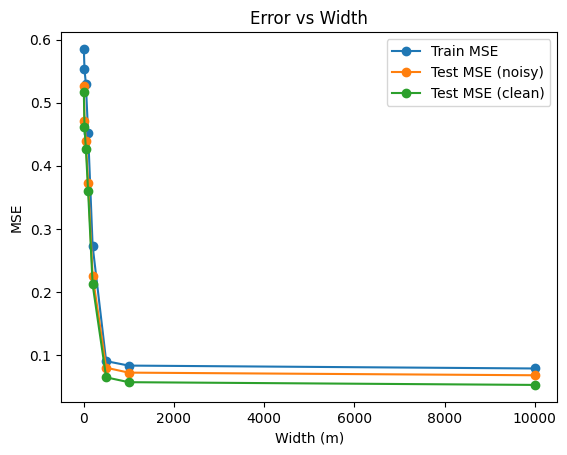

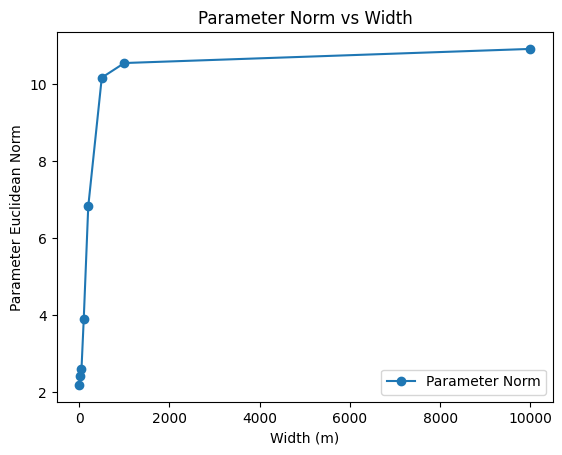

Widths: [5, 20, 50, 100, 200, 500, 1000, 10000]
Train MSE: [0.5851120644659218, 0.5527622437160957, 0.52984477895995, 0.4515099882427155, 0.2731608313906738, 0.0904384070409687, 0.08339601979152891, 0.07881012484315734]
Test MSE (noisy): [0.5264739933431538, 0.4706288942248297, 0.4391046973618603, 0.3724979154135094, 0.2259022627778821, 0.08000847122502616, 0.07223655107571494, 0.06806096948379156]
Test MSE (clean): [0.5172644944369504, 0.46080005051770423, 0.4273334936133084, 0.3598009472317954, 0.21200066581922572, 0.06478739320234699, 0.05708959022450303, 0.05275996717258256]
Param Norms: [2.1899901957077774, 2.429317257122648, 2.5964162582641572, 3.8904926794872545, 6.819500082310535, 10.161485021491462, 10.540747318977825, 10.906624092317307]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(0)

def f(x):
    return np.sin(4 * np.pi * x)

# Data
n_train = 50
n_test = 50
noise_std = 0.1

X_train = rng.uniform(0, 1, size=(n_train, 1))
y_train_clean = f(X_train[:, 0])
y_train = y_train_clean + rng.normal(0, noise_std, size=n_train)

X_test = rng.uniform(0, 1, size=(n_test, 1))
y_test_clean = f(X_test[:, 0])
y_test_noisy = y_test_clean + rng.normal(0, noise_std, size=n_test)

widths = [5, 20, 50, 100, 200, 500]
n_repeats = 5

results = {m: {"train": [], "test_noisy": [], "test_clean": [], "norm": []} for m in widths}
models = {}

for m in widths:
    for rep in range(n_repeats):
        model = MLPRegressor(
            hidden_layer_sizes=(m,),
            activation="relu",
            solver="adam",
            alpha=0.0,
            max_iter=5000,
            random_state=rep,
        )
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_err = mean_squared_error(y_train, y_train_pred)
        test_noisy_err = mean_squared_error(y_test_noisy, y_test_pred)
        test_clean_err = mean_squared_error(y_test_clean, y_test_pred)

        # Parameter norm
        sq_sum = 0.0
        for coef, intercept in zip(model.coefs_, model.intercepts_):
            sq_sum += np.sum(coef**2) + np.sum(intercept**2)
        param_norm = np.sqrt(sq_sum)

        results[m]["train"].append(train_err)
        results[m]["test_noisy"].append(test_noisy_err)
        results[m]["test_clean"].append(test_clean_err)
        results[m]["norm"].append(param_norm)

        models[m] = model

# Aggregate means
train_means = [np.mean(results[m]["train"]) for m in widths]
test_noisy_means = [np.mean(results[m]["test_noisy"]) for m in widths]
test_clean_means = [np.mean(results[m]["test_clean"]) for m in widths]
norm_means = [np.mean(results[m]["norm"]) for m in widths]



# Plot errors vs width
plt.figure()
plt.plot(widths, train_means, marker='o', label='Train MSE')
plt.plot(widths, test_noisy_means, marker='o', label='Test MSE (noisy)')
plt.plot(widths, test_clean_means, marker='o', label='Test MSE (clean)')
# plt.xscale("log")
plt.xlabel("Width (m)")
plt.ylabel("MSE")
plt.title("Error vs Width")
plt.legend()
plt.show()

# Plot parameter norm vs width
plt.figure()
plt.plot(widths, norm_means, marker='o', label='Parameter Norm')
# plt.xscale("log")
plt.xlabel("Width (m)")
plt.ylabel("Parameter Euclidean Norm")
plt.title("Parameter Norm vs Width")
plt.legend()
plt.show()

print("Widths:", widths)
print("Train MSE:", train_means)
print("Test MSE (noisy):", test_noisy_means)
print("Test MSE (clean):", test_clean_means)
print("Param Norms:", norm_means)


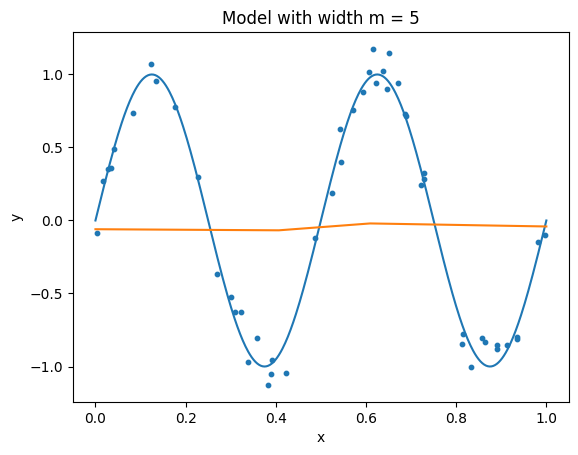

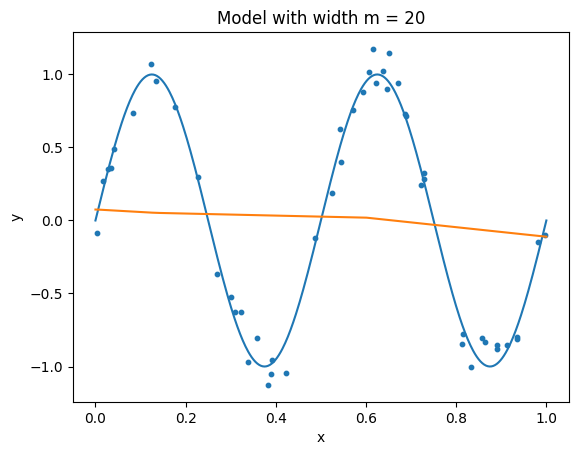

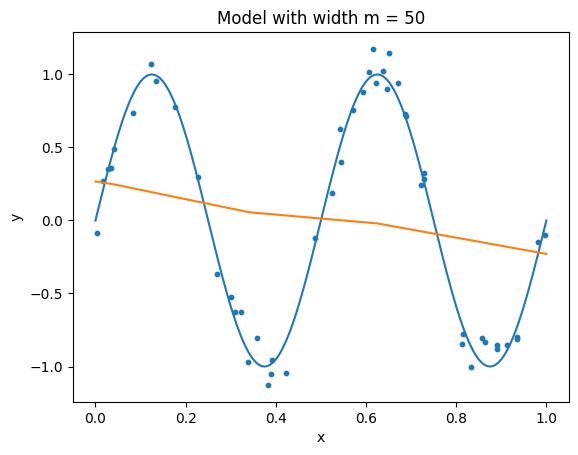

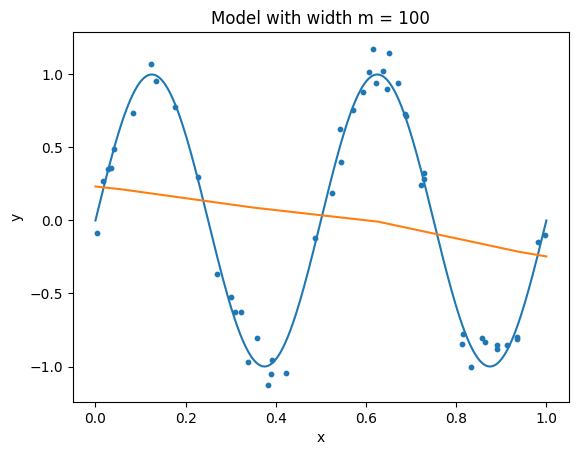

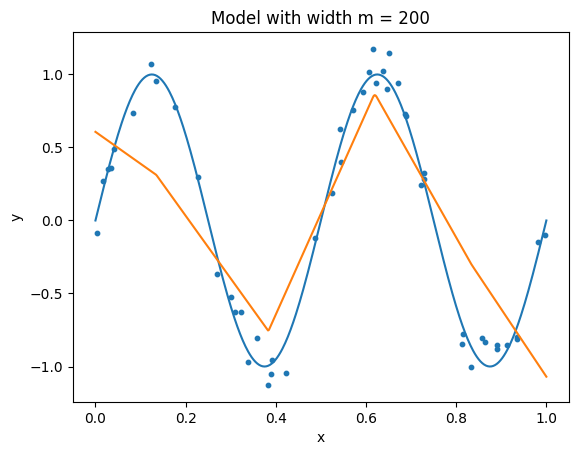

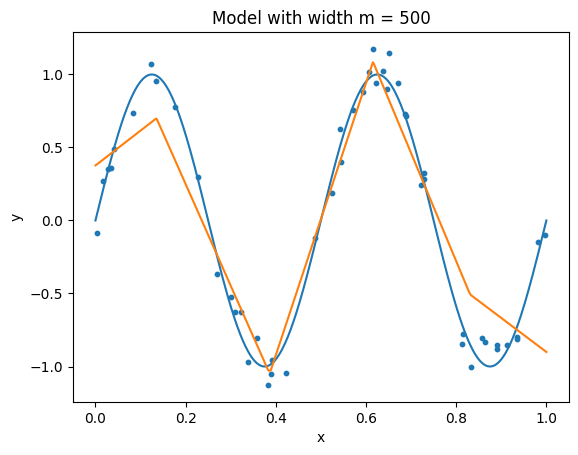

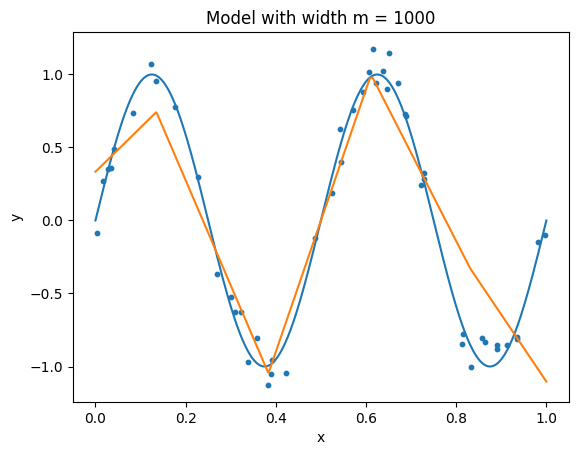

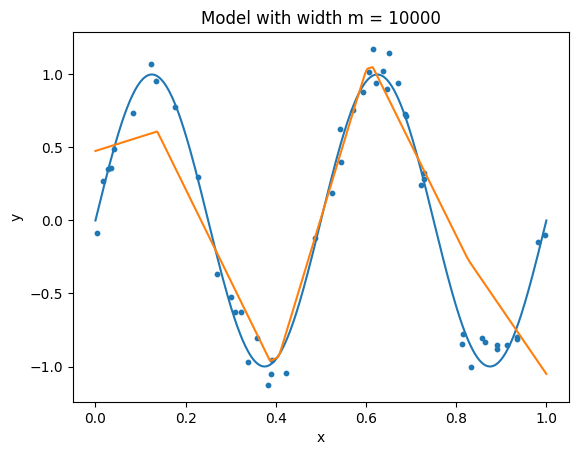

In [6]:

# Plot predictions for smallest and largest networks
x_plot = np.linspace(0, 1, 500).reshape(-1, 1)
y_true_plot = f(x_plot[:, 0])

for m in widths:
    plt.figure()
    plt.plot(x_plot[:, 0], y_true_plot)
    plt.scatter(X_train[:, 0], y_train, s=10)
    plt.plot(x_plot[:, 0], models[m].predict(x_plot))
    plt.title(f"Model with width m = {m}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()